In [4]:
import seaborn as sns
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [5]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix

In [6]:
data=sns.load_dataset('titanic')
data=data[['age','fare','sex','class','survived']].dropna()

In [7]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
data['sex']=le.fit_transform(data['sex'])
data['class']=le.fit_transform(data['class'])

In [9]:
data

,age,fare,sex,class,survived
0,22.0,7.2500,1,2,0
1,38.0,71.2833,0,0,1
2,26.0,7.9250,0,2,1
3,35.0,53.1000,0,0,1
4,35.0,8.0500,1,2,0
...,...,...,...,...,...
885,39.0,29.1250,0,2,0
886,27.0,13.0000,1,1,0
887,19.0,30.0000,0,0,1
889,26.0,30.0000,1,0,1


In [10]:
x=data[['age','fare','sex','class']].values
y=data['survived'].values

In [11]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=47)

In [13]:
scaler=StandardScaler()
x_train=scaler.fit_transform(x_train)
x_test=scaler.fit_transform(x_test)

In [14]:
model=Sequential([
    Dense(100,activation='relu',input_shape=(4,)),         #input layer
    Dense(89,activation='relu'),                           #hidden layers
    Dense(80,activation='relu'),


    Dense(1,activation='sigmoid')                          #output layer
])

c:\Users\admin\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [15]:
model.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])

In [16]:
histroy=model.fit(x_train,y_train,epochs=50,batch_size=32,validation_split=0.2)

Epoch 1/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 3s 28ms/step - accuracy: 0.7325 - loss: 0.6142 - val_accuracy: 0.7391 - val_loss: 0.5799
Epoch 2/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.7895 - loss: 0.4748 - val_accuracy: 0.7478 - val_loss: 0.5626
Epoch 3/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8026 - loss: 0.4301 - val_accuracy: 0.7652 - val_loss: 0.5852
Epoch 4/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8114 - loss: 0.4162 - val_accuracy: 0.7217 - val_loss: 0.5804
Epoch 5/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7895 - loss: 0.4081 - val_accuracy: 0.7391 - val_loss: 0.5631
Epoch 6/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8246 - loss: 0.4023 - val_accuracy: 0.7304 - val_loss: 0.5732
Epoch 7/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8355 - loss: 0.3967 - val_accuracy: 0.7391 - val_loss: 0.5756
Epoch 8/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8136 - loss: 0.3926 - val_accuracy: 0.7304 - val

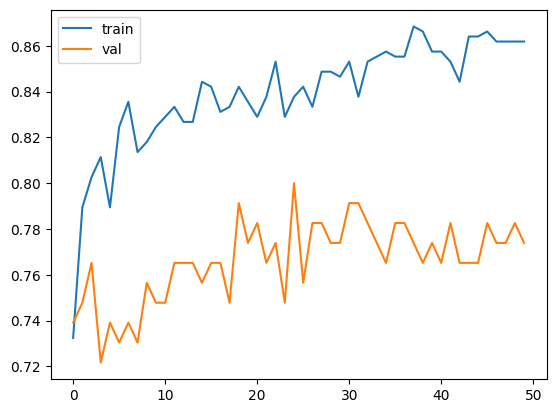

In [19]:
import matplotlib.pyplot as plt
plt.plot(histroy.history['accuracy'],label='train')
plt.plot(histroy.history['val_accuracy'],label='val')
plt.legend()
plt.show()


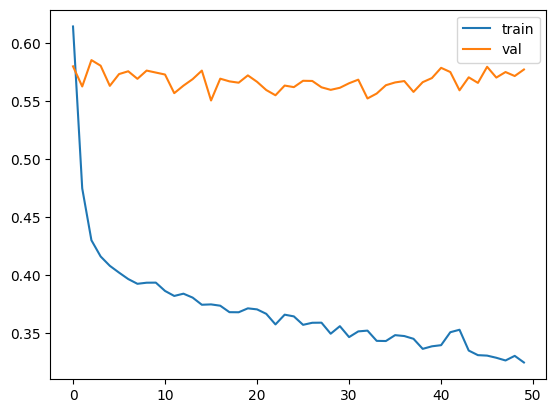

In [20]:
import matplotlib.pyplot as plt
plt.plot(histroy.history['loss'],label='train')
plt.plot(histroy.history['val_loss'],label='val')
plt.legend()
plt.show()
